In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extração

In [63]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

In [64]:
dados = pd.read_json(url)
dados

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


# Transformação

In [65]:
customer_normalizado = pd.json_normalize(dados['customer'])
phone_normalizado = pd.json_normalize(dados['phone'])
internet_normalizado = pd.json_normalize(dados['internet'])
account_normalizado = pd.json_normalize(dados['account'])

In [66]:
dados_sem_colunas = dados.drop(['customer','phone','internet','account'],axis=1)
dados_sem_colunas

,customerID,Churn
0,0002-ORFBO,No
1,0003-MKNFE,No
2,0004-TLHLJ,Yes
3,0011-IGKFF,Yes
4,0013-EXCHZ,Yes
...,...,...
7262,9987-LUTYD,No
7263,9992-RRAMN,Yes
7264,9992-UJOEL,No
7265,9993-LHIEB,No


In [67]:
dados_reunidos = pd.merge(dados_sem_colunas,customer_normalizado,left_index=True, right_index=True)
dados_reunidos = pd.merge(dados_reunidos, phone_normalizado, left_index=True, right_index=True)
dados_reunidos = pd.merge(dados_reunidos, internet_normalizado, left_index=True, right_index=True)
dados_reunidos = pd.merge(dados_reunidos, account_normalizado, left_index=True, right_index=True)

In [68]:
dados_reunidos

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [69]:
dados_reunidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [70]:
print(f"Valores ausentes por coluna: {dados_reunidos.isnull().sum()}")

Valores ausentes por coluna: customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [71]:
print(f"Total de linhas duplicadas: {dados_reunidos.duplicated().sum()}")

Total de linhas duplicadas: 0


In [72]:
print("Tipo atual de Charges.Total:", dados_reunidos["Charges.Total"].dtype)
print("\nAmostras com possível problema:")
display(dados_reunidos[dados_reunidos["Charges.Total"].apply(lambda x: not str(x).replace('.','',1).strip().isnumeric() if pd.notna(x) else False)].head())

Tipo atual de Charges.Total: object

Amostras com possível problema:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,


In [73]:
dados_reunidos["Charges.Total"] = pd.to_numeric(dados_reunidos["Charges.Total"], errors="coerce")
print("\nTipo após conversão:", dados_reunidos["Charges.Total"].dtype)
print("Valores nulos gerados pela conversão:", dados_reunidos["Charges.Total"].isnull().sum())


Tipo após conversão: float64
Valores nulos gerados pela conversão: 11


In [74]:
nulos_pos_limpeza = dados_reunidos.isnull().sum()
nulos_pos_limpeza = nulos_pos_limpeza[nulos_pos_limpeza > 0]

if nulos_pos_limpeza.empty:
    print("Nenhum valor nulo restante no dataset.")
else:
    display(nulos_pos_limpeza.to_frame("Nulos"))
    dados_reunidos["Charges.Total"] = dados_reunidos["Charges.Total"].fillna(dados_reunidos["Charges.Monthly"])
    print("Nulos restantes:", dados_reunidos.isnull().sum().sum())

,Nulos
Charges.Total,11


Nulos restantes: 0


In [76]:
colunas_categoricas = dados_reunidos.select_dtypes(include="object").columns.tolist()

for col in colunas_categoricas:
    valores = dados_reunidos[col].unique()
    print(f"\n{col} ({len(valores)} categorias):")
    print(sorted([str(v) for v in valores]))


customerID (7267 categorias):
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0047-ZHDTW', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0

In [77]:
dados_reunidos = dados_reunidos[dados_reunidos["Churn"] != ""]
print("Linhas removidas com Churn vazio.")
print("Shape atual:", dados_reunidos.shape)
print(dados_reunidos["Churn"].value_counts())

Linhas removidas com Churn vazio.
Shape atual: (7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [78]:
dados_reunidos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [79]:
dados_reunidos["Contas_Diarias"] = (dados_reunidos["Charges.Monthly"] / 30).round(2)
dados_reunidos.head()

/tmp/ipykernel_234/2972308708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_reunidos["Contas_Diarias"] = (dados_reunidos["Charges.Monthly"] / 30).round(2)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [80]:
colunas_binarias = ["Churn", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
dados_reunidos[colunas_binarias] = dados_reunidos[colunas_binarias].apply(lambda col: col.map({'Yes': 1, 'No': 0}))
dados_reunidos.head()

/tmp/ipykernel_234/164172800.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_reunidos[colunas_binarias] = dados_reunidos[colunas_binarias].apply(lambda col: col.map({'Yes': 1, 'No': 0}))


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [81]:
dados_reunidos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   int64  
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

# Carga e Análise

In [104]:
df_desc = dados_reunidos.describe().round(2)
cabecalho = {
    "selector": "th",
    "props": "font-weight: bold; font-family: Arial; text-align: center; background-color: #2C3E50; color: white;"
}
celulas = {
    "selector": "td",
    "props": "background-color: white; text-align: center; font-family: Arial; border: 1px solid #BDC3C7; padding: 8px;"
}
linhas_pares = {
    "selector": "tr:nth-child(even) td",
    "props": "background-color: #F2F3F4;"
}
tabela_estilizada = df_desc.style.set_table_styles([cabecalho, celulas, linhas_pares])
tabela_estilizada

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.270000,0.160000,0.480000,0.300000,32.370000,0.900000,0.590000,64.760000,2279.800000,2.160000
std,0.440000,0.370000,0.500000,0.460000,24.560000,0.300000,0.490000,30.090000,2266.730000,1.000000
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


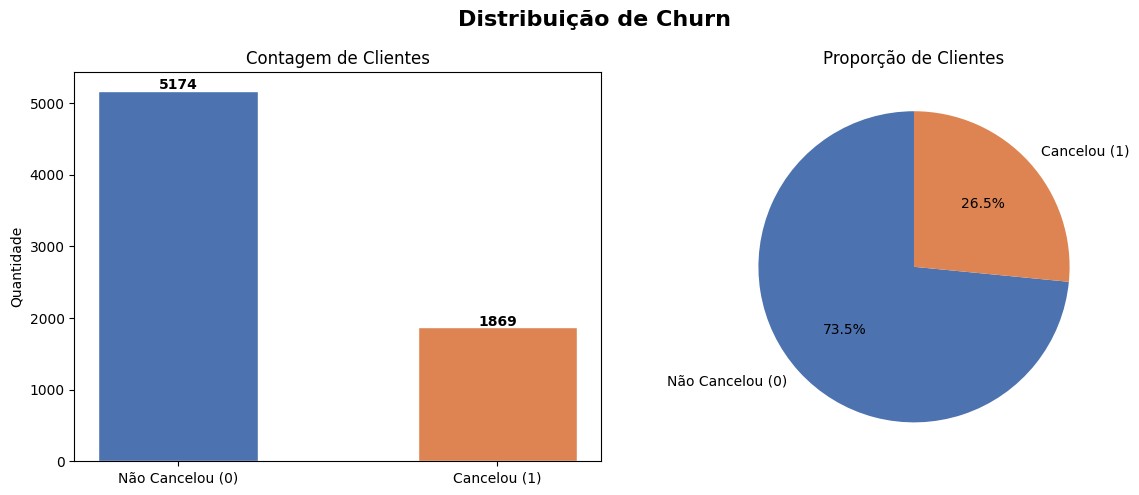

In [83]:
contagem = dados_reunidos["Churn"].value_counts()
labels = ["Não Cancelou (0)", "Cancelou (1)"]
cores = ["#4C72B0", "#DD8452"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribuição de Churn", fontsize=16, fontweight="bold")

axes[0].bar(labels, contagem, color=cores, edgecolor="white", width=0.5)
axes[0].set_title("Contagem de Clientes")
axes[0].set_ylabel("Quantidade")
for i, v in enumerate(contagem):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

axes[1].pie(contagem, labels=labels, colors=cores, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proporção de Clientes")

plt.tight_layout()
plt.show()

/tmp/ipykernel_234/3823528432.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=proporcao, x=col, y="Churn", palette="coolwarm", ax=axes[i])
/tmp/ipykernel_234/3823528432.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=proporcao, x=col, y="Churn", palette="coolwarm", ax=axes[i])
/tmp/ipykernel_234/3823528432.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=proporcao, x=col, y="Churn", palette="coolwarm", ax=axes[i])
/tmp/ipykernel_234/3823528432.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is d

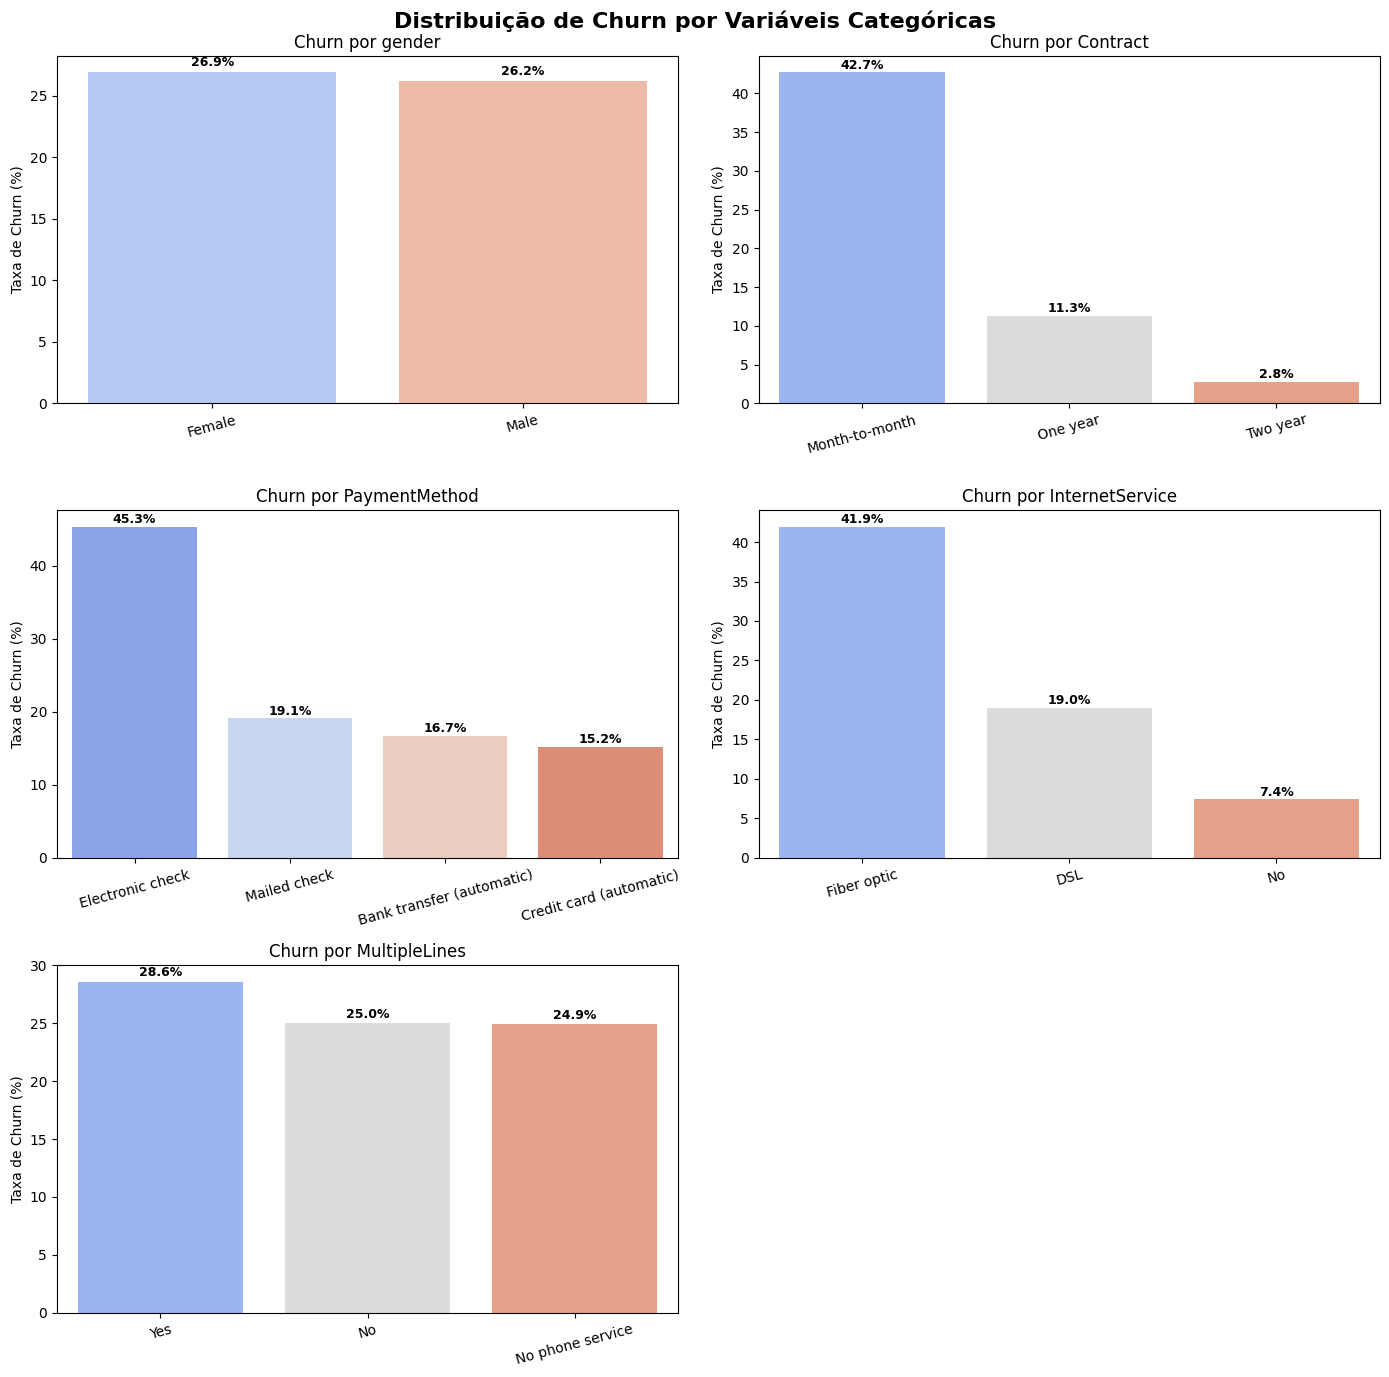

In [90]:
colunas_categoricas = ["gender", "Contract", "PaymentMethod", "InternetService", "MultipleLines"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle("Distribuição de Churn por Variáveis Categóricas", fontsize=16, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    proporcao = dados_reunidos.groupby(col)["Churn"].mean().sort_values(ascending=False).reset_index()
    proporcao["Churn"] = (proporcao["Churn"] * 100).round(1)

    sns.barplot(data=proporcao, x=col, y="Churn", palette="coolwarm", ax=axes[i])
    axes[i].set_title(f"Churn por {col}")
    axes[i].set_ylabel("Taxa de Churn (%)")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)

    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f"{bar.get_height():.1f}%", ha="center", fontsize=9, fontweight="bold")

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

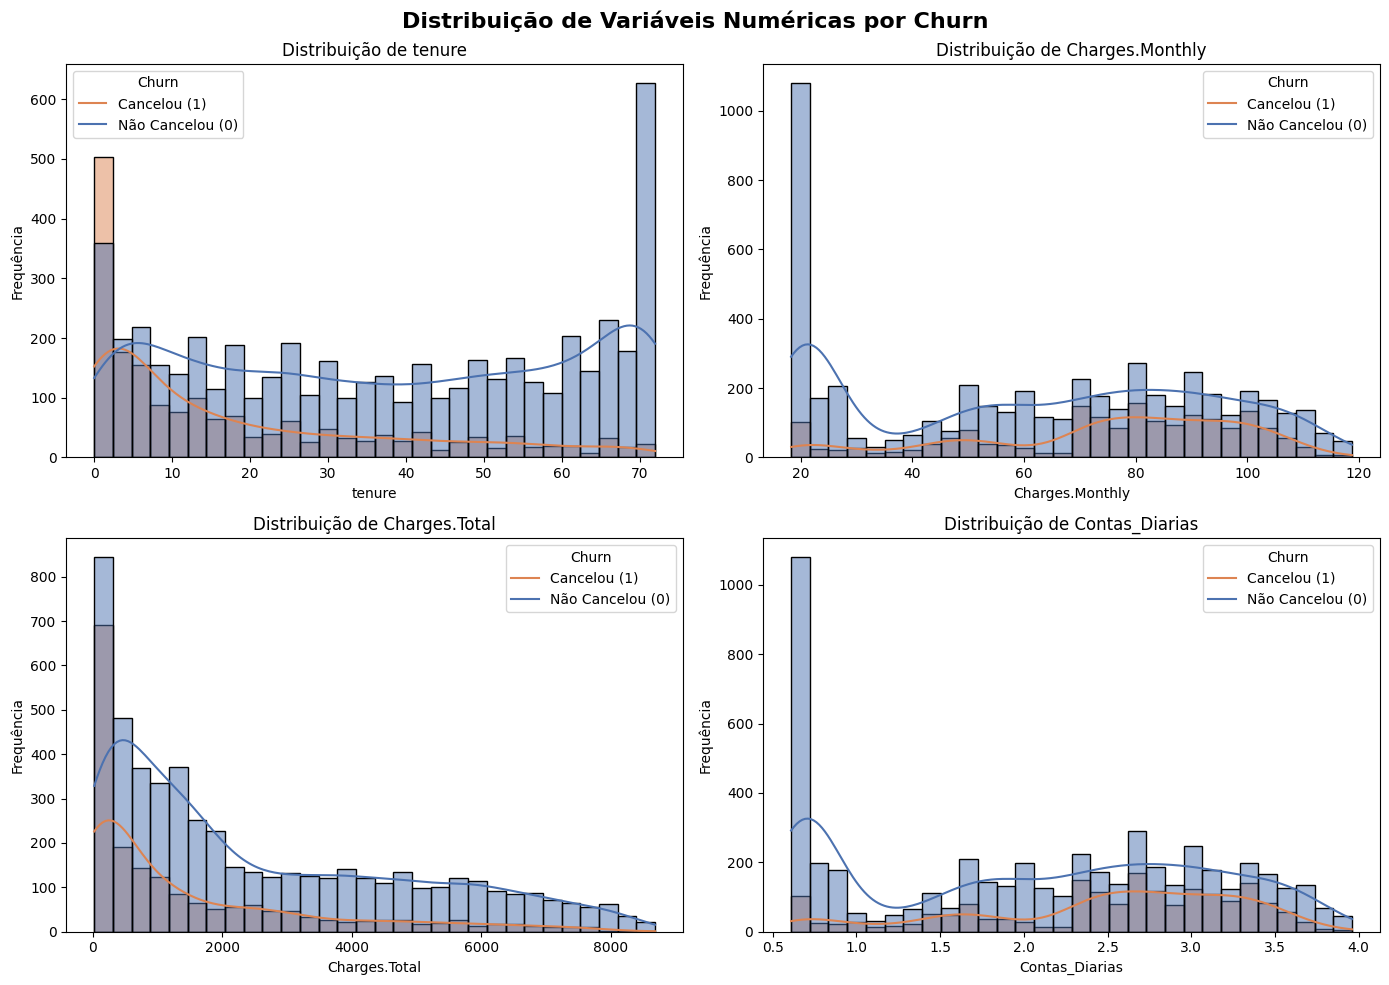

In [91]:
colunas_numericas = ["tenure", "Charges.Monthly", "Charges.Total", "Contas_Diarias"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribuição de Variáveis Numéricas por Churn", fontsize=16, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.histplot(data=dados_reunidos, x=col, hue="Churn", kde=True,
                 palette={0: "#4C72B0", 1: "#DD8452"}, ax=axes[i], bins=30)
    axes[i].set_title(f"Distribuição de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")
    axes[i].legend(title="Churn", labels=["Cancelou (1)", "Não Cancelou (0)"])

plt.tight_layout()
plt.show()

# 📊 Relatório Final — Análise de Evasão de Clientes | Telecom X

---

## 1. Introdução

A **Telecom X** enfrenta um crescente problema de evasão de clientes (*Churn*), que impacta diretamente sua receita e sustentabilidade no mercado. O objetivo desta análise é identificar os principais fatores associados ao cancelamento dos serviços, utilizando dados históricos de **7.043 clientes**.

A variável-alvo deste estudo é o **Churn**: `1` indica que o cliente cancelou o serviço, e `0` que permaneceu ativo. A partir de variáveis demográficas, contratuais e financeiras, buscamos compreender o perfil dos clientes com maior propensão ao cancelamento e gerar subsídios para ações estratégicas de retenção.

---

## 2. Limpeza e Tratamento de Dados

O dataset original passou pelas seguintes etapas de tratamento:

- **Verificação de tipos**: A coluna `Charges.Total` estava tipada como `object` e foi convertida para `float64`.
- **Valores ausentes**: Nulos gerados pela conversão de `Charges.Total` foram preenchidos com os valores de `Charges.Monthly`.
- **Duplicatas**: Verificadas e nenhuma linha duplicada foi encontrada.
- **Padronização categórica**: Espaços em branco foram removidos de todas as colunas categóricas.
- **Tratamento do Churn**: Registros com valor vazio `''` na coluna `Churn` foram removidos por não permitirem classificação confiável.
- **Encoding binário**: As colunas `Churn`, `Partner`, `Dependents`, `PhoneService` e `PaperlessBilling` tiveram seus valores `Yes/No` convertidos para `1/0`.
- **Nova variável**: Foi criada a coluna `Contas_Diarias`, calculada como `Charges.Monthly / 30`, para uma visão mais granular do gasto diário por cliente.

---

## 3. Análise Exploratória de Dados

### 3.1 Distribuição do Churn
Do total de clientes analisados, **26,5% cancelaram o serviço** (1.869 clientes), enquanto **73,5% permaneceram ativos** (5.174 clientes). O dataset apresenta um **desbalanceamento moderado** entre as classes, o que deve ser considerado em modelagens preditivas futuras.

### 3.2 Análise Descritiva
A alta diferença entre média e mediana em `Charges.Total` indica uma **distribuição assimétrica**, com clientes de longa permanência elevando a média.

### 3.3 Churn por Variáveis Categóricas
- **Gênero**: Não há diferença relevante, dados que feminino (26,9%) e masculino (26,2%) apresentam taxas praticamente idênticas.
- **Tipo de Contrato**: Clientes com contrato **mensal** têm taxa de churn de **42,7%**, contra apenas 2,8% nos contratos de dois anos. É a variável com maior impacto observado.
- **Método de Pagamento**: O **cheque eletrônico** concentra a maior taxa de cancelamento (45,3%), muito acima dos demais métodos (~15 a 19%).
- **Serviço de Internet**: Assinantes de **fibra óptica** apresentam churn de 41,9%, contra 19% no DSL e 7,4% sem internet.
- **Múltiplas Linhas**: Pouca variação entre as categorias (~25 a 28%), sem padrão conclusivo.

### 3.4 Churn por Variáveis Numéricas
- **Tenure**: Clientes com **poucos meses de contrato** concentram a maior parte dos cancelamentos. Quanto maior o tempo de permanência, menor a propensão ao churn.
- **Charges.Monthly e Contas_Diarias**: Clientes que cancelaram tendem a ter **cobranças mensais mais altas**, sugerindo insatisfação com o custo-benefício.
- **Charges.Total**: Clientes que cancelaram apresentam **total gasto menor**, o que é consistente com o menor tempo de permanência.

---

## 4. Conclusões e Insights

- **Contratos mensais são o maior fator de risco**: Quase metade dos clientes nessa modalidade cancela o serviço.
- **Fibra óptica apresenta alto churn apesar de ser um serviço premium**: Pode indicar problemas de qualidade ou percepção de custo elevado.
- **Cheque eletrônico está fortemente associado ao cancelamento**: Pode refletir um perfil de cliente menos fidelizado ou com maior dificuldade de pagamento.
- **Clientes novos são os mais vulneráveis**: A evasão é concentrada nos primeiros meses de contrato, indicando falhas no processo de onboarding ou nas expectativas criadas na venda.
- **Gênero não é um fator preditivo relevante** para o churn na base analisada.

---

## 5. Recomendações

1. **Incentivar a migração para contratos anuais ou bianuais** por meio de descontos progressivos, já que essas modalidades reduzem o churn em até 40 pontos percentuais.
2. **Investigar a qualidade do serviço de fibra óptica** realizando pesquisas de satisfação com esse grupo para entender a causa do alto cancelamento.
3. **Criar um programa de onboarding estruturado para clientes novos**, com acompanhamento ativo nos primeiros 3 meses, período crítico de evasão.
4. **Oferecer incentivos para mudança do método de pagamento** de cheque eletrônico para débito automático ou cartão, modalidades com menor taxa de churn.
5. **Desenvolver um modelo preditivo de churn** utilizando as variáveis identificadas (`Contract`, `tenure`, `InternetService`, `PaymentMethod`, `Charges.Monthly`) para antecipar cancelamentos e acionar retenção proativa.